In [2]:
%pip install --upgrade transformers --user

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Object Detection
%pip install timm
%pip install Pillow

# Using the model directly
from transformers import DetrImageProcessor, DetrForObjectDetection
image_processor = DetrImageProcessor.from_pretrained(
"facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained(
"facebook/detr-resnet-50")

# To know what objects the model was trained to detect
model.config.id2label

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


'[Errno 104] Connection reset by peer' thrown while requesting HEAD https://huggingface.co/facebook/detr-resnet-50/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].
'[Errno 104] Connection reset by peer' thrown while requesting HEAD https://huggingface.co/facebook/detr-resnet-50/resolve/main/processor_config.json
Retrying in 2s [Retry 2/5].
'[Errno 104] Connection reset by peer' thrown while requesting HEAD https://huggingface.co/facebook/detr-resnet-50/resolve/main/processor_config.json
Retrying in 4s [Retry 3/5].
'[Errno 104] Connection reset by peer' thrown while requesting HEAD https://huggingface.co/facebook/detr-resnet-50/resolve/main/processor_config.json
Retrying in 8s [Retry 4/5].
'[Errno 104] Connection reset by peer' thrown while requesting HEAD https://huggingface.co/facebook/detr-resnet-50/resolve/main/processor_config.json
Retrying in 8s [Retry 5/5].
'[Errno 104] Connection reset by peer' thrown while requesting HEAD https://huggingface.co/facebook/detr-resne

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


{0: 'N/A',
 1: 'person',
 10: 'traffic light',
 11: 'fire hydrant',
 12: 'street sign',
 13: 'stop sign',
 14: 'parking meter',
 15: 'bench',
 16: 'bird',
 17: 'cat',
 18: 'dog',
 19: 'horse',
 2: 'bicycle',
 20: 'sheep',
 21: 'cow',
 22: 'elephant',
 23: 'bear',
 24: 'zebra',
 25: 'giraffe',
 26: 'hat',
 27: 'backpack',
 28: 'umbrella',
 29: 'shoe',
 3: 'car',
 30: 'eye glasses',
 31: 'handbag',
 32: 'tie',
 33: 'suitcase',
 34: 'frisbee',
 35: 'skis',
 36: 'snowboard',
 37: 'sports ball',
 38: 'kite',
 39: 'baseball bat',
 4: 'motorcycle',
 40: 'baseball glove',
 41: 'skateboard',
 42: 'surfboard',
 43: 'tennis racket',
 44: 'bottle',
 45: 'plate',
 46: 'wine glass',
 47: 'cup',
 48: 'fork',
 49: 'knife',
 5: 'airplane',
 50: 'spoon',
 51: 'bowl',
 52: 'banana',
 53: 'apple',
 54: 'sandwich',
 55: 'orange',
 56: 'broccoli',
 57: 'carrot',
 58: 'hot dog',
 59: 'pizza',
 6: 'bus',
 60: 'donut',
 61: 'cake',
 62: 'chair',
 63: 'couch',
 64: 'potted plant',
 65: 'bed',
 66: 'mirror',
 67

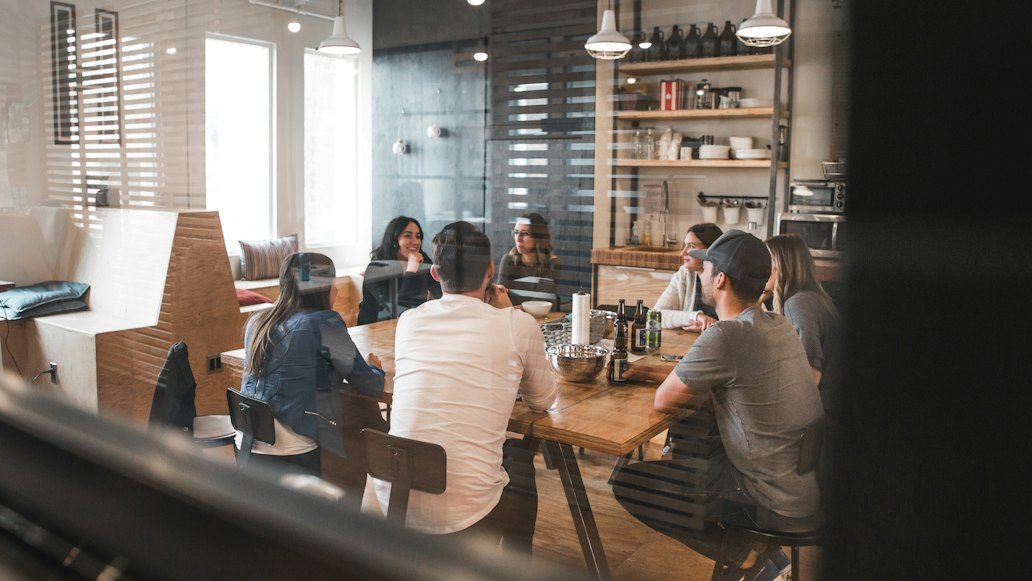

In [27]:
from PIL import Image, ImageDraw
import requests
import torch

def loadImage(url):
    if url.startswith('http'):
        image = Image.open(requests.get(url, stream=True).raw)
    else:
        image = Image.open(url)
    return image

image = loadImage('https://images.unsplash.com/photo-1568992687947-868a62a9f521?q=80&w=1032&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D')
display(image)


In [28]:
inputs = image_processor(images = image, return_tensors="pt")
# print(inputs)

outputs = model(**inputs)

In [29]:
target_sizes = torch.tensor([image.size[::-1]])

results = image_processor.post_process_object_detection(outputs, 
                                                        target_sizes = target_sizes, 
                                                        threshold = 0.9)[0]
results

print(results)
print(f"Image is a {model.config.id2label[results['labels'][0].item()]}")
'''
Summary of that post_process_object_detection, output of the model that was created earlier
- Target size of the image
- Threshold value for filtering out predictions (in this case, return only those with
confidence greater than 90%)
'''

{'scores': tensor([0.9884, 0.9071, 0.9270, 0.9424, 0.9404, 0.9971, 0.9504, 0.9533, 0.9729,
        0.9087, 0.9629, 0.9979, 0.9839, 0.9995, 0.9358, 0.9981, 0.9922, 0.9870,
        0.9309, 0.9013, 0.9969, 0.9992], grad_fn=<IndexBackward0>), 'labels': tensor([62, 44, 44, 67, 82,  1, 44, 67, 62,  1,  1,  1, 62,  1, 44,  1,  1, 51,
        51, 44, 51,  1]), 'boxes': tensor([[ 2.2271e+02,  3.8357e+02,  3.1726e+02,  4.6947e+02],
        [ 6.4763e+02,  3.0333e+02,  6.6302e+02,  3.5076e+02],
        [ 6.3141e+02,  2.9955e+02,  6.4759e+02,  3.5197e+02],
        [ 3.5823e+02,  2.5883e+02,  4.3826e+02,  3.2053e+02],
        [ 8.1733e+02,  4.0087e+00,  1.0310e+03,  5.7468e+02],
        [ 4.9592e+02,  2.1215e+02,  5.5975e+02,  3.0831e+02],
        [ 6.0984e+02,  3.0361e+02,  6.2913e+02,  3.7601e+02],
        [-1.5529e-01,  2.0546e+02,  2.3790e+02,  4.1725e+02],
        [ 3.5553e+02,  4.2484e+02,  4.5303e+02,  5.3347e+02],
        [ 3.7117e+02,  2.1743e+02,  4.3357e+02,  3.0814e+02],
        [ 3.7446

'\nSummary of that post_process_object_detection, output of the model that was created earlier\n- Target size of the image\n- Threshold value for filtering out predictions (in this case, return only those with\nconfidence greater than 90%)\n'

Detected chair with confidence 98.84% at [222.71, 383.57, 317.26, 469.47]
Detected bottle with confidence 90.71% at [647.63, 303.33, 663.02, 350.76]
Detected bottle with confidence 92.70% at [631.41, 299.55, 647.59, 351.97]
Detected dining table with confidence 94.24% at [358.23, 258.83, 438.26, 320.53]
Detected refrigerator with confidence 94.04% at [817.33, 4.01, 1030.97, 574.68]
Detected person with confidence 99.71% at [495.92, 212.15, 559.75, 308.31]
Detected bottle with confidence 95.04% at [609.84, 303.61, 629.13, 376.01]
Detected dining table with confidence 95.33% at [-0.16, 205.46, 237.9, 417.25]
Detected chair with confidence 97.29% at [355.53, 424.84, 453.03, 533.47]
Detected person with confidence 90.87% at [371.17, 217.43, 433.57, 308.14]
Detected person with confidence 96.29% at [374.46, 216.7, 430.29, 275.77]
Detected person with confidence 99.79% at [239.35, 255.15, 383.57, 460.74]
Detected chair with confidence 98.39% at [235.93, 234.83, 299.66, 282.79]
Detected perso

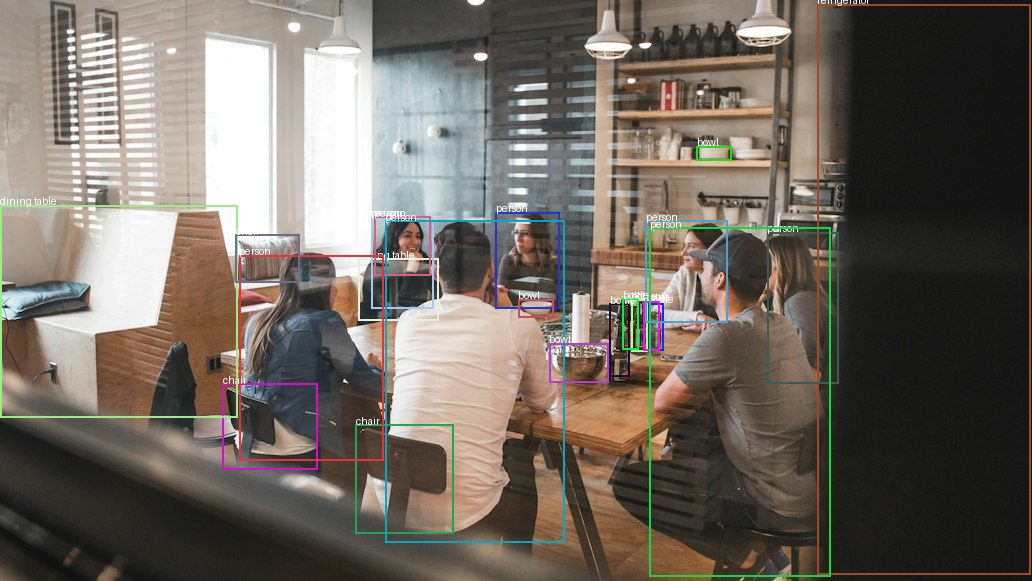

In [30]:
# Drawing bounding boxes around the detected objects
import random

draw = ImageDraw.Draw(image)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    box= [round(i, 2) for i in box.tolist()]
    print(
        f"Detected {model.config.id2label[label.item()]} with confidence "
        f"{(score.item() * 100):.2f}% at {box}"
    )
    r = random.randint(0, 255)
    g = random.randint(0, 255)
    b = random.randint(0, 255)
    color = (r, g, b)

    # Draw bounding box around object 
    draw.rectangle(box, outline=color, width=2)

    # Display the object label
    draw.text((box[0], box[1]-10), model.config.id2label[label.item()], fill='white')

display(image)

In [31]:
# Using the transformers pipeline
from transformers import pipeline

detection = pipeline("object-detection", model="facebook/detr-resnet-50")

results = detection(image)
results

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[{'score': 0.5554531812667847,
  'label': 'backpack',
  'box': {'xmin': 148, 'ymin': 337, 'xmax': 199, 'ymax': 431}},
 {'score': 0.5649296045303345,
  'label': 'bottle',
  'box': {'xmin': 632, 'ymin': 129, 'xmax': 648, 'ymax': 160}},
 {'score': 0.6195765137672424,
  'label': 'handbag',
  'box': {'xmin': 229, 'ymin': 384, 'xmax': 320, 'ymax': 458}},
 {'score': 0.7247397303581238,
  'label': 'bottle',
  'box': {'xmin': 671, 'ymin': 23, 'xmax': 688, 'ymax': 56}},
 {'score': 0.544850766658783,
  'label': 'cup',
  'box': {'xmin': 739, 'ymin': 202, 'xmax': 760, 'ymax': 224}},
 {'score': 0.7659710049629211,
  'label': 'bottle',
  'box': {'xmin': 703, 'ymin': 21, 'xmax': 719, 'ymax': 55}},
 {'score': 0.5551193356513977,
  'label': 'dining table',
  'box': {'xmin': 517, 'ymin': 359, 'xmax': 809, 'ymax': 575}},
 {'score': 0.5991868376731873,
  'label': 'bowl',
  'box': {'xmin': 741, 'ymin': 147, 'xmax': 770, 'ymax': 157}},
 {'score': 0.5092465281486511,
  'label': 'handbag',
  'box': {'xmin': 23

Detected backpack with confidence55.55% at [148, 337, 199, 431]
Detected bottle with confidence56.49% at [632, 129, 648, 160]
Detected handbag with confidence61.96% at [229, 384, 320, 458]
Detected bottle with confidence72.47% at [671, 23, 688, 56]
Detected cup with confidence54.49% at [739, 202, 760, 224]
Detected bottle with confidence76.60% at [703, 21, 719, 55]
Detected dining table with confidence55.51% at [517, 359, 809, 575]
Detected bowl with confidence59.92% at [741, 147, 770, 157]
Detected handbag with confidence50.92% at [235, 389, 308, 455]
Detected bowl with confidence69.54% at [738, 154, 767, 166]
Detected bowl with confidence91.83% at [518, 299, 556, 316]
Detected bowl with confidence82.92% at [735, 138, 764, 151]
Detected bottle with confidence73.46% at [721, 20, 737, 55]
Detected bottle with confidence72.88% at [693, 22, 710, 55]
Detected person with confidence98.55% at [380, 220, 438, 312]
Detected bottle with confidence61.45% at [638, 129, 653, 160]
Detected person w

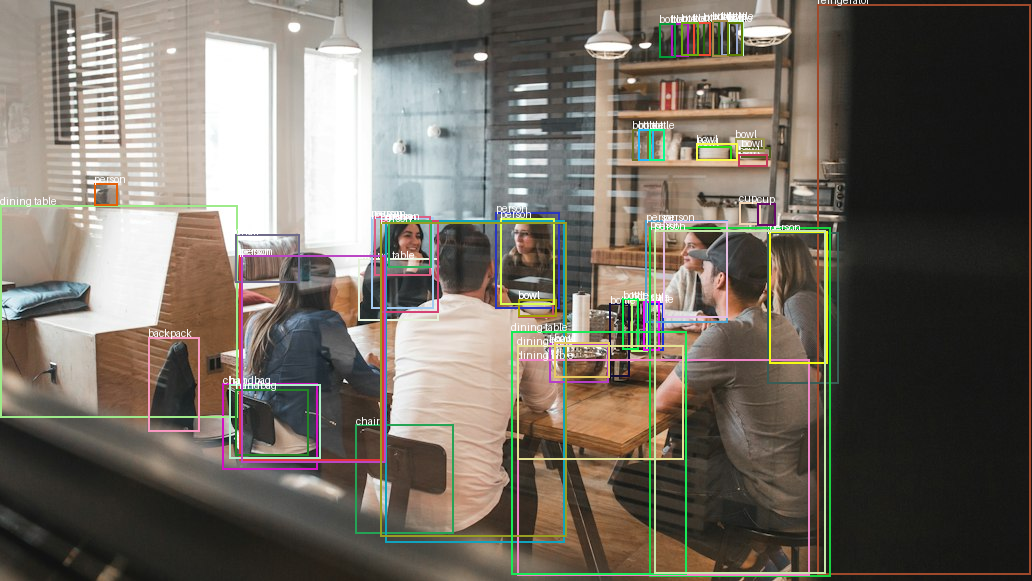

In [34]:
# Visualizing detected objects with bounding boxes
import random

draw = ImageDraw.Draw(image)

for object in results:
    box = [i for i in object['box'].values()]
    print(
        f"Detected {object['label']} with confidence"
        f"{(object['score'] * 100):.2f}% at {box}"
    )
    r = random.randint(0, 255)
    g = random.randint(0, 255)
    b = random.randint(0, 255)
    color = (r, g, b)

    # Draw bounding box around object
    draw.rectangle(
        box,
        outline=color,
        width=2
    )

    # Display the object label
    draw.text(
        (box[0], box[1]-10),
        object['label'],
        fill='white'
    )

display(image)

In [3]:
# Binding to webcam
!pip install --upgrade numpy opencv-python

INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install numpy and opencv-python==5.0.0.93 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested numpy
    opencv-python 5.0.0.93 depends on numpy>=2; python_version >= "3.9"

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip attempt to solve the dependency conflict

ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [2]:
import cv2

# Use default webcam
stream = cv2.VideoCapture(0)
while(True):
    # Capturing frame by frame 
    (grabbed, frame) = stream.read()
    # Show the frame
    cv2.imshow("Image", frame)
    key = cv2.waitKey(1) & 0xFF
    # Press q to break out of the loop
    if key == ord("q"):
        break

# Cleaning up
stream.release()
cv2.waitKey(1)
cv2.destroyAllWindows()
cv2.waitKey(1)

[ WARN:0@0.025] global cap_v4l.cpp:914 open VIDEOIO(V4L2:/dev/video0): can't open camera by index
[ WARN:0@0.027] global cap.cpp:435 open VIDEOIO(FFMPEG): raised OpenCV exception:

OpenCV(5.0.0) /io/opencv/modules/videoio/src/cap_ffmpeg_impl.hpp:1243: error: (-2:Unspecified error) in function 'bool CvCapture_FFMPEG::open(const char*, int, const cv::Ptr<cv::IStreamReader>&, const cv::VideoCaptureParameters&)'
> VIDEOIO/FFMPEG: Camera index out of range (expected: 'index < device_list->nb_devices'), where
>     'index' is 0
> must be less than
>     'device_list->nb_devices' is 0


[ WARN:0@0.028] global obsensor_stream_channel_v4l2.cpp:82 xioctl ioctl: fd=-1, req=-2140645888
[ WARN:0@0.028] global obsensor_stream_channel_v4l2.cpp:138 queryUvcDeviceInfoList ioctl error return: 9
[ WARN:0@0.028] global obsensor_stream_channel_v4l2.cpp:82 xioctl ioctl: fd=-1, req=-2140645888
[ WARN:0@0.028] global obsensor_stream_channel_v4l2.cpp:138 queryUvcDeviceInfoList ioctl error return: 9
[ERROR:0@0.

error: OpenCV(5.0.0) /io/opencv/modules/highgui/src/window.cpp:951: error: (-215:Assertion failed) size.width>0 && size.height>0 in function 'imshow'


In [3]:
# Detecting objects in the webcam
from transformers import pipeline
from PIL import Image
import cv2
# Font, color and line thickness for drawing rectangle ad text
font = cv2.FONT_HERSHEY_SIMPLEX
color = (0, 255, 255)
stroke = 2
# Loads the object detection model
detection = pipeline(
                    "object-detection",
                    model="facebook/detr-resnet-50"
                    )
stream = cv2.VidoeCapture(0)
while(True):
    # Capturing frame by frame
    (grabbed, frame) = stream.read()
    # Convert the video image from Numpy array to a PIL image
    image = Image.fromarray(frame)
    # Detects objects in the image 
    results = detection(image)
    for object in results:
        # Gets the coordinates for the object detected
        box = [i for i in object['box'].values()]
        # Draw bounding box around object detected
        cv2.rectangle(
            frame,
            (box[0], box[1]),
            (box[2], box[3]),
            color,
            stroke
        )
        # Draw the label for the object
        cv2.putText(
            frame,
            f'({object["label"]})',
            (box[0], box[1]-8),
            font, 
            1,
            color,
            stroke,
            cv2.LINE_AA
        )
    # Show the frame
    cv2.imshow("Image", frame)
    key = cv2.waitKey(1) & 0xFF
    # Press q to break out of the loop 
    if key == ord("q"):
        break

# Cleaning up
stream.release()
cv2.waitKey(1)
cv2.destroyAllWindows()
cv2.waitKey(1)

'''
Summary: here I can't prove its success because I use in jupyter notebook
'''

/opt/conda/lib/python3.11/site-packages/scipy/__init__.py:132: UserWarning: A NumPy version >=1.21.6 and <1.28.0 is required for this version of SciPy (detected version 2.4.6)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


ImportError: cannot import name 'Inf' from 'numpy' (/opt/conda/lib/python3.11/site-packages/numpy/__init__.py)

In [11]:
# Image Classification
from transformers import pipeline

classifier = pipeline("image-classification", model="ibombonato/vit-age-classifier")

prediction = classifier('https://images.unsplash.com/photo-1619895862022-09114b41f16f?q=80&w=1170&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D')
print(prediction)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Invalid model-index. Not loading eval results into CardData.


[{'label': '30-40', 'score': 0.9784302711486816}, {'label': '40-50', 'score': 0.011519053019583225}, {'label': '20-30', 'score': 0.00277567352168262}, {'label': '0-10', 'score': 0.0015046756016090512}, {'label': '80-90', 'score': 0.0011354844318702817}]


In [13]:
# Image Segmentation
from transformers import pipeline

segmentation = pipeline("image-segmentation", model="nvidia/segformer-b0-finetuned-ade-512-512")

# check list all object can be detected
segmentation.model.config.id2label

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 15.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

{0: 'wall',
 1: 'building',
 2: 'sky',
 3: 'floor',
 4: 'tree',
 5: 'ceiling',
 6: 'road',
 7: 'bed ',
 8: 'windowpane',
 9: 'grass',
 10: 'cabinet',
 11: 'sidewalk',
 12: 'person',
 13: 'earth',
 14: 'door',
 15: 'table',
 16: 'mountain',
 17: 'plant',
 18: 'curtain',
 19: 'chair',
 20: 'car',
 21: 'water',
 22: 'painting',
 23: 'sofa',
 24: 'shelf',
 25: 'house',
 26: 'sea',
 27: 'mirror',
 28: 'rug',
 29: 'field',
 30: 'armchair',
 31: 'seat',
 32: 'fence',
 33: 'desk',
 34: 'rock',
 35: 'wardrobe',
 36: 'lamp',
 37: 'bathtub',
 38: 'railing',
 39: 'cushion',
 40: 'base',
 41: 'box',
 42: 'column',
 43: 'signboard',
 44: 'chest of drawers',
 45: 'counter',
 46: 'sand',
 47: 'sink',
 48: 'skyscraper',
 49: 'fireplace',
 50: 'refrigerator',
 51: 'grandstand',
 52: 'path',
 53: 'stairs',
 54: 'runway',
 55: 'case',
 56: 'pool table',
 57: 'pillow',
 58: 'screen door',
 59: 'stairway',
 60: 'river',
 61: 'bridge',
 62: 'bookcase',
 63: 'blind',
 64: 'coffee table',
 65: 'toilet',
 66: '

In [15]:
from PIL import Image
import requests

url = 'https://images.unsplash.com/photo-1487553333251-6c8e26d3dc2c?q=80&w=687&auto=format&fit=crop&ixlib=rb-4.1.0&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D'
results = segmentation(url)
results

[{'score': None,
  'label': 'wall',
  'mask': <PIL.Image.Image image mode=L size=687x1031>},
 {'score': None,
  'label': 'building',
  'mask': <PIL.Image.Image image mode=L size=687x1031>},
 {'score': None,
  'label': 'sky',
  'mask': <PIL.Image.Image image mode=L size=687x1031>},
 {'score': None,
  'label': 'person',
  'mask': <PIL.Image.Image image mode=L size=687x1031>},
 {'score': None,
  'label': 'airplane',
  'mask': <PIL.Image.Image image mode=L size=687x1031>}]

wall


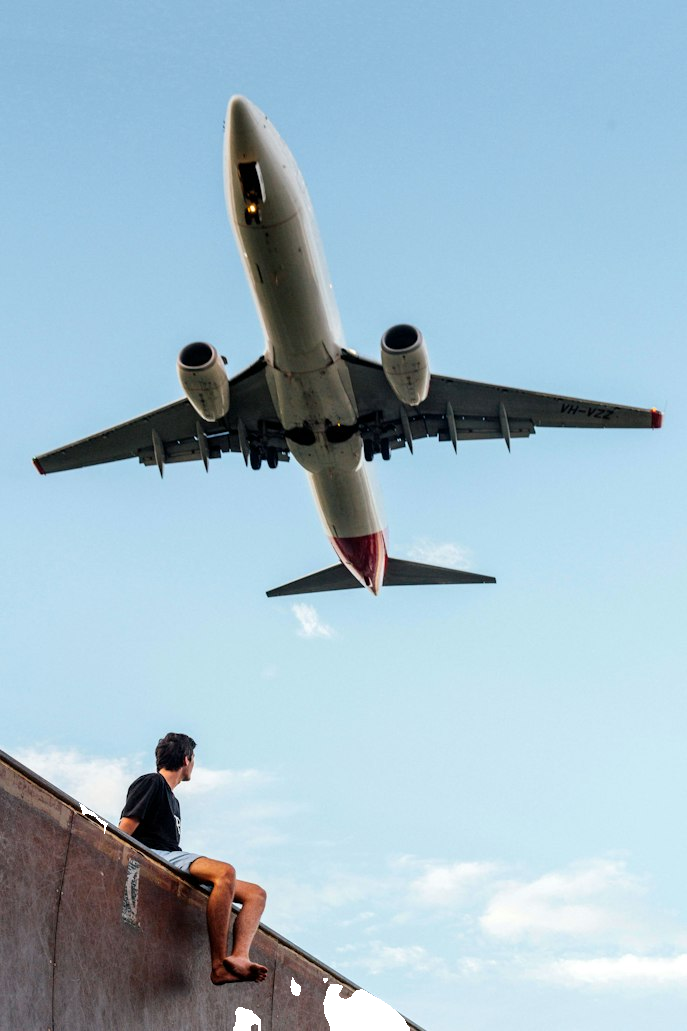

building


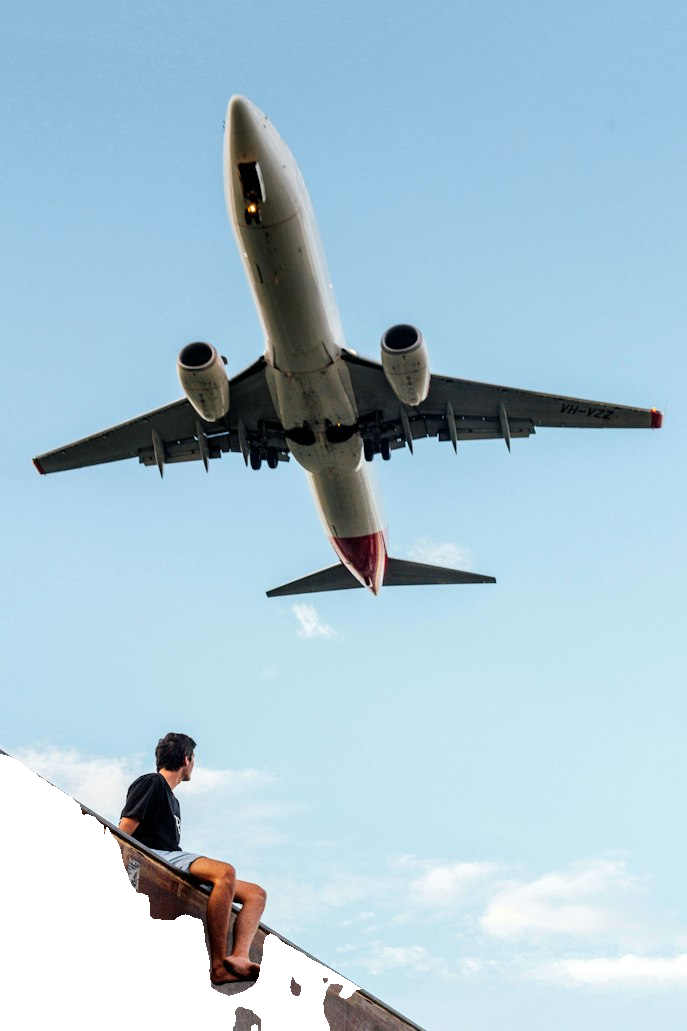

sky


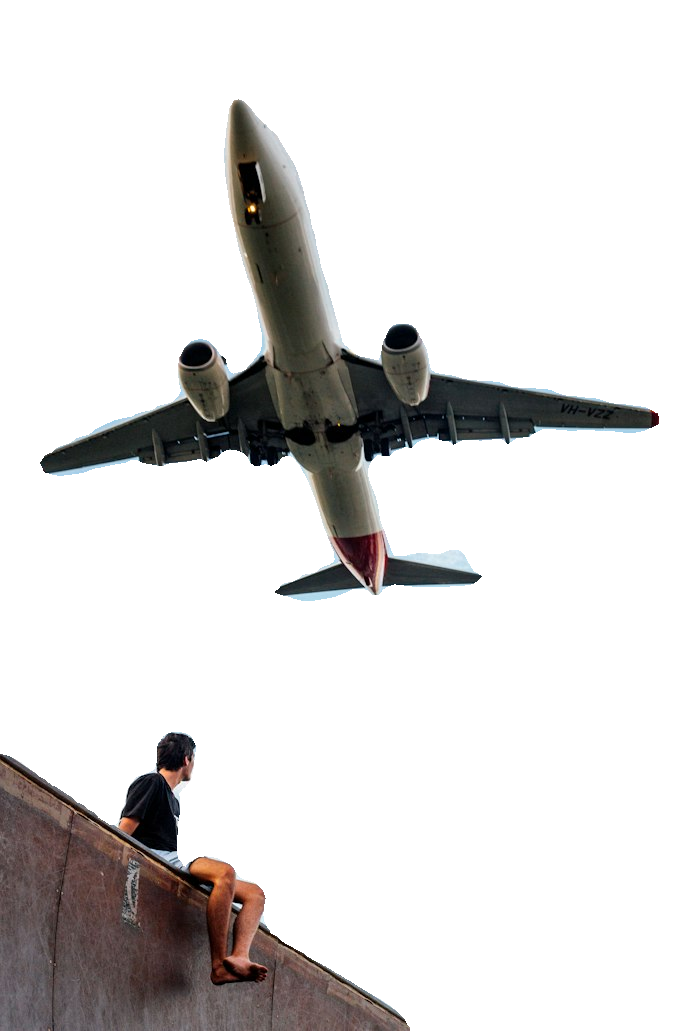

person


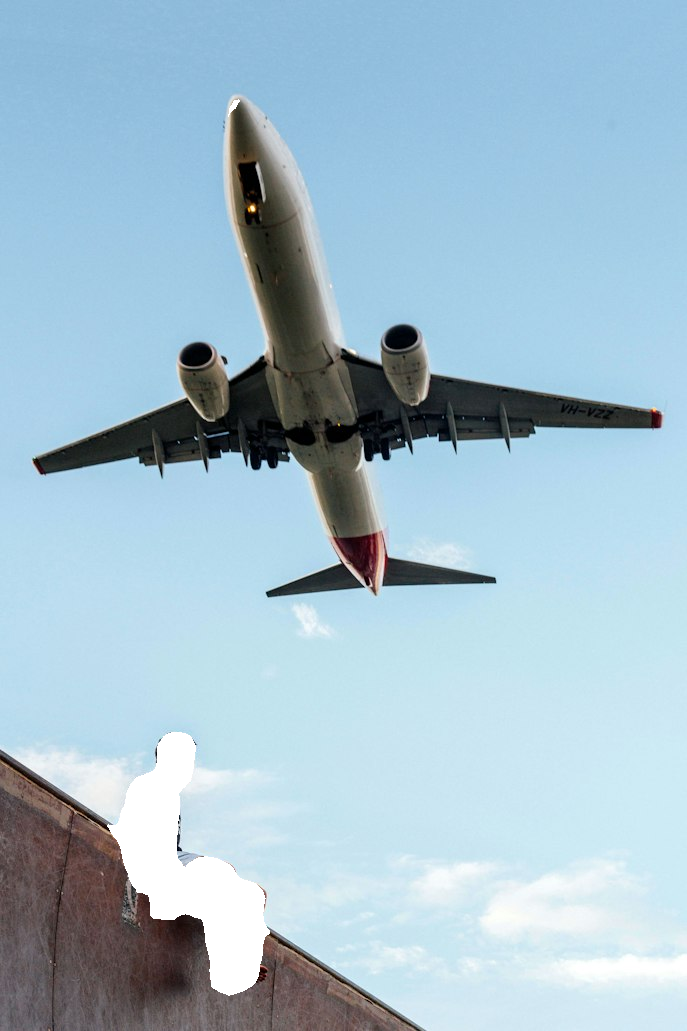

airplane


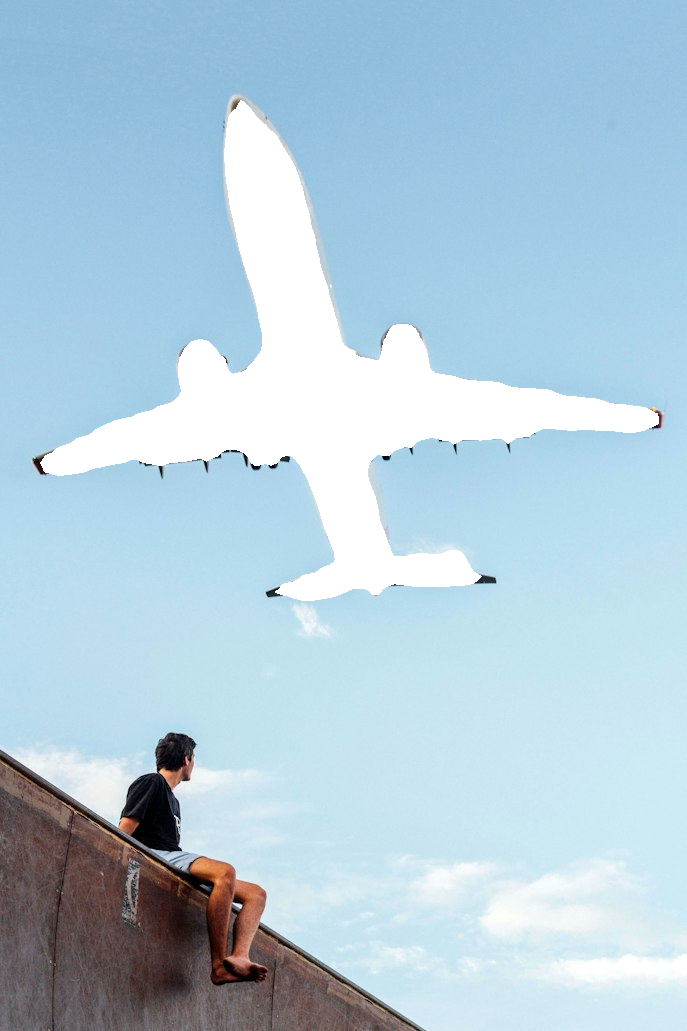

In [18]:
# Separate object detected mask

image = Image.open(requests.get(url, stream=True).raw)

for result in results:
    # print(result['label'])
    # display(result['mask'])
    base_image = image.copy()
    mask_image = result['mask']

    # Applies the mask over the original image
    base_image.paste(mask_image, mask=mask_image)
    print(result['label'])
    display(base_image)

In [ ]:
# Oter way separate object detected mask
from PIL import ImageOps

for result in results:
    base_image = image.copy()
    mask_image = result['mask']

    # invert the mask
    mask_image = ImageOps.invert(mask_image)
    base_image.paste(mask_image, mask=mask_image)
    print(result['label'])
    display(base_image)

In [2]:
# Binding to Gradio
!pip install gradio

In [8]:
from transformers import SegformerForSemanticSegmentation, pipeline

model = pipeline("image-segmentation", model="nvidia/segformer-b0-finetuned-ade-512-512")

def segmentation(image, label):
    # Converts image from NumPy array to PIL format
    image = Image.fromarray(image)
    # Uses the model for inferencing
    results = model(image)
    for result in results:
        if result['label'] == label:
            base_image = image.copy()
            mask_image = result['mask']
            # Inverts the mask
            mask_image = ImageOps.invert(mask_image)
            # Applies the mask over the original image
            base_image.paste(mask_image, mask = mask_image)
            return(base_image)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

In [9]:
# use gradio for UI
import gradio as gr

image_input = gr.Image(label = "Image to segmentize")

label = gr.Textbox(label = "Label to look for", placeholder = "Label")

image_output = gr.Image(label = "Image with the mask applied")

gr.Interface(segmentation, 
            [image_input, label],
            image_output
            ).launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://453358ac2d9b578476.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:
# Video classification
%pip install decord
%pip install av
%pip install torchcodec

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [18]:
from transformers import pipeline
video_classifier = pipeline(
                            "video-classification", 
                            model="MCG-NJU/videomae-base-short-finetuned-kinetics"
                            )

# Check model capable of recognizing
video_classifier.model.config.id2label

Loading weights:   0%|          | 0/162 [00:00<?, ?it/s]

[transformers] VideoMAEForVideoClassification LOAD REPORT from: MCG-NJU/videomae-base-short-finetuned-kinetics
Key                                                            | Status     | 
---------------------------------------------------------------+------------+-
videomae.encoder.layer.{0...11}.attention.attention.q_bias     | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.v_bias     | UNEXPECTED | 
videomae.encoder.layer.{0...11}.attention.attention.key.bias   | MISSING    | 
videomae.encoder.layer.{0...11}.attention.attention.value.bias | MISSING    | 
videomae.encoder.layer.{0...11}.attention.attention.query.bias | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{0: 'abseiling',
 1: 'air drumming',
 2: 'answering questions',
 3: 'applauding',
 4: 'applying cream',
 5: 'archery',
 6: 'arm wrestling',
 7: 'arranging flowers',
 8: 'assembling computer',
 9: 'auctioning',
 10: 'baby waking up',
 11: 'baking cookies',
 12: 'balloon blowing',
 13: 'bandaging',
 14: 'barbequing',
 15: 'bartending',
 16: 'beatboxing',
 17: 'bee keeping',
 18: 'belly dancing',
 19: 'bench pressing',
 20: 'bending back',
 21: 'bending metal',
 22: 'biking through snow',
 23: 'blasting sand',
 24: 'blowing glass',
 25: 'blowing leaves',
 26: 'blowing nose',
 27: 'blowing out candles',
 28: 'bobsledding',
 29: 'bookbinding',
 30: 'bouncing on trampoline',
 31: 'bowling',
 32: 'braiding hair',
 33: 'breading or breadcrumbing',
 34: 'breakdancing',
 35: 'brush painting',
 36: 'brushing hair',
 37: 'brushing teeth',
 38: 'building cabinet',
 39: 'building shed',
 40: 'bungee jumping',
 41: 'busking',
 42: 'canoeing or kayaking',
 43: 'capoeira',
 44: 'carrying baby',
 45: 'c

In [20]:
video_classifier('http://192.168.8.129:7777/work/HF_Projects/pexels-pat-whelen.mp4')

'''
Summary it is not work! need update in future
'''

OSError: Could not load this library: /opt/conda/lib/python3.11/site-packages/torchcodec/libtorchcodec_image.so